# VoltRelay Energy — Data Analytics

Run the complete chunk-based analysis and inspect the generated results.

In [17]:
import os
print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'voltrelay_dataset.zip', 'sample_data']


In [18]:
!ls -lh /content/voltrelay_dataset.zip

-rw-r--r-- 1 root root 159M Sep 27 09:43 /content/voltrelay_dataset.zip


In [19]:
!ls -lh /content/voltrelay_dataset.zip

-rw-r--r-- 1 root root 159M Sep 27 09:43 /content/voltrelay_dataset.zip


In [20]:
!unzip -t /content/voltrelay_dataset.zip

Archive:  /content/voltrelay_dataset.zip
    testing: stations.csv             OK
    testing: support_tickets.csv      OK
    testing: batteries.csv            OK
    testing: riders.csv               OK
    testing: city_daily_context.csv   OK
    testing: fleet_partners.csv       OK
    testing: station_hourly_status.csv   OK
    testing: swap_events.csv          OK
No errors detected in compressed data of /content/voltrelay_dataset.zip.


In [21]:
import os

!mkdir -p /content/data
!unzip -q /content/voltrelay_dataset.zip -d /content/data

print("Dataset extracted successfully!")
print(os.listdir("/content/data"))

Dataset extracted successfully!
['fleet_partners.csv', 'support_tickets.csv', 'city_daily_context.csv', 'station_hourly_status.csv', 'stations.csv', 'batteries.csv', 'swap_events.csv', 'riders.csv']


In [22]:
import pandas as pd

swap = pd.read_csv("/content/data/swap_events.csv")

print("Dataset loaded successfully!")
print("Rows:", len(swap))
print("Columns:", len(swap.columns))

print("\nColumns:")
print(swap.columns.tolist())

swap.head()

Dataset loaded successfully!
Rows: 3877013
Columns: 22

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,...,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,...,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,...,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,...,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,...,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [23]:
# STEP 6 - Network Performance KPIs

completed = (swap["event_type"] == "swap_completed").sum()
total_attempts = len(swap)
unsuccessful = total_attempts - completed

success_rate = completed / total_attempts * 100
failure_rate = unsuccessful / total_attempts * 100

total_revenue = swap["amount_charged_inr"].sum()
avg_revenue = swap["amount_charged_inr"].mean()
avg_queue = swap["queue_wait_sec"].mean()
avg_soh = swap["soh_in_pct"].mean()

print("=" * 60)
print("VOLTRELAY ENERGY - NETWORK PERFORMANCE")
print("=" * 60)

print(f"Total swap attempts      : {total_attempts:,}")
print(f"Completed swaps          : {completed:,}")
print(f"Unsuccessful attempts    : {unsuccessful:,}")

print(f"\nSuccess rate             : {success_rate:.2f}%")
print(f"Failure rate             : {failure_rate:.2f}%")

print(f"\nTotal amount charged     : ₹{total_revenue:,.2f}")
print(f"Average amount charged   : ₹{avg_revenue:.2f}")
print(f"Average queue wait       : {avg_queue:.2f} seconds")
print(f"Average battery SOH      : {avg_soh:.2f}%")

print("\nEvent Type Breakdown:")
print(swap["event_type"].value_counts())

VOLTRELAY ENERGY - NETWORK PERFORMANCE
Total swap attempts      : 3,877,013
Completed swaps          : 3,645,809
Unsuccessful attempts    : 231,204

Success rate             : 94.04%
Failure rate             : 5.96%

Total amount charged     : ₹233,126,055.55
Average amount charged   : ₹60.13
Average queue wait       : 242.95 seconds
Average battery SOH      : 88.17%

Event Type Breakdown:
event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64


In [24]:
# STEP 7 - Monthly Network Performance

swap["event_ts"] = pd.to_datetime(swap["event_ts"], errors="coerce")

swap["month"] = swap["event_ts"].dt.to_period("M").astype(str)

monthly = swap.groupby("month").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    revenue=("amount_charged_inr", "sum"),
    avg_queue_wait=("queue_wait_sec", "mean")
).reset_index()

monthly["success_rate"] = (
    monthly["completed_swaps"] /
    monthly["total_attempts"] * 100
)

monthly["failure_rate"] = 100 - monthly["success_rate"]

print(monthly.to_string(index=False))

  month  total_attempts  completed_swaps     revenue  avg_queue_wait  success_rate  failure_rate
2024-01          110348           105490  6318995.20      242.286711     95.597564      4.402436
2024-02          111531           106582  6387614.80      243.473169     95.562669      4.437331
2024-03          123900           118444  7093617.00      242.204730     95.596449      4.403551
2024-04          131818           122836  7370255.80      243.329720     93.186060      6.813940
2024-05          146278           128328  7689594.00      242.733945     87.728845     12.271155
2024-06          148888           133743  8003275.60      242.320268     89.827924     10.172076
2024-07          158688           151824  9879524.60      243.129657     95.674531      4.325469
2024-08          172295           164931 10724296.65      243.255022     95.725935      4.274065
2024-09          195885           187302 12115209.50      242.907696     95.618347      4.381653
2024-10          229901       

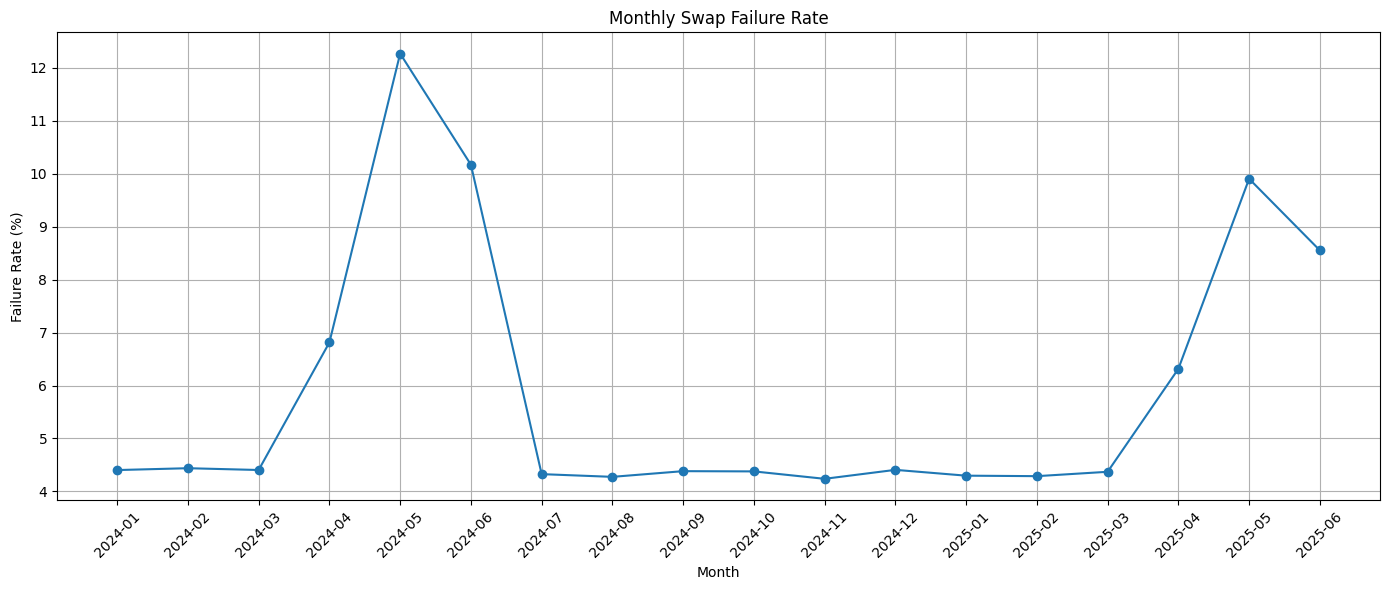

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly["month"],
    monthly["failure_rate"],
    marker="o"
)

plt.title("Monthly Swap Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# STEP 9 - Station Performance

station_perf = swap.groupby("station_id").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    avg_queue_wait=("queue_wait_sec", "mean"),
    revenue=("amount_charged_inr", "sum")
).reset_index()

station_perf["failure_rate"] = (
    1 - station_perf["completed_swaps"] /
    station_perf["total_attempts"]
) * 100

# Only consider stations with reasonable activity
station_perf_filtered = station_perf[
    station_perf["total_attempts"] >= 1000
].copy()

# Highest failure-rate stations
top_failure_stations = station_perf_filtered.sort_values(
    "failure_rate",
    ascending=False
).head(10)

print("Top 10 stations by failure rate:")
print(
    top_failure_stations[
        [
            "station_id",
            "total_attempts",
            "completed_swaps",
            "failure_rate",
            "avg_queue_wait",
            "revenue"
        ]
    ].to_string(index=False)
)

Top 10 stations by failure rate:
 station_id  total_attempts  completed_swaps  failure_rate  avg_queue_wait    revenue
STN-DEL-037           30838            28039      9.076464      242.635871 1753081.65
STN-DEL-048           34646            31535      8.979392      243.989119 1942066.85
STN-JAI-137           44371            40490      8.746704      242.782583 2529267.85
STN-JAI-142           33319            30405      8.745761      244.333623 1946904.75
STN-JAI-141           45594            41613      8.731412      243.734088 2528249.90
STN-DEL-045           32237            29426      8.719794      243.086795 1835646.25
STN-JAI-136           29340            26785      8.708248      241.874131 1747866.15
STN-JAI-138           48945            44703      8.666871      243.439636 2804974.60
STN-DEL-040           40335            36848      8.645097      242.694236 2364370.60
STN-DEL-050           47060            43007      8.612410      242.044284 2639130.25


In [27]:
# STEP 10 - City-wise Performance

stations = pd.read_csv("/content/data/stations.csv")

print("Stations loaded:", len(stations))
print(stations.columns.tolist())

Stations loaded: 152
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']


In [28]:
# STEP 10 - City-wise Performance

# Add city information to swap events
swap_city = swap.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_perf = swap_city.groupby("city").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    revenue=("amount_charged_inr", "sum"),
    avg_queue_wait=("queue_wait_sec", "mean")
).reset_index()

city_perf["success_rate"] = (
    city_perf["completed_swaps"] /
    city_perf["total_attempts"] * 100
)

city_perf["failure_rate"] = (
    100 - city_perf["success_rate"]
)

city_perf = city_perf.sort_values(
    "failure_rate",
    ascending=False
)

print("City-wise Performance:")
print(city_perf.to_string(index=False))

City-wise Performance:
     city  total_attempts  completed_swaps     revenue  avg_queue_wait  success_rate  failure_rate
   Jaipur          487634           449366 28229052.85      243.276693     92.152311      7.847689
Delhi NCR          768913           712385 44565107.85      242.722361     92.648323      7.351677
Hyderabad          711930           664312 41521622.25      242.785407     93.311421      6.688579
     Pune          552910           525331 34766281.90      243.007462     95.012027      4.987973
Bengaluru          825327           787697 51954743.25      242.900433     95.440595      4.559405
   Mumbai          530299           506718 32089247.45      243.244164     95.553263      4.446737


In [29]:
# STEP 11 - Charger Generation Performance

charger_perf = swap.merge(
    stations[["station_id", "charger_generation"]],
    on="station_id",
    how="left"
)

charger_analysis = charger_perf.groupby("charger_generation").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    avg_queue_wait=("queue_wait_sec", "mean"),
    revenue=("amount_charged_inr", "sum")
).reset_index()

charger_analysis["success_rate"] = (
    charger_analysis["completed_swaps"] /
    charger_analysis["total_attempts"] * 100
)

charger_analysis["failure_rate"] = (
    100 - charger_analysis["success_rate"]
)

print("Charger Generation Performance:")
print(charger_analysis.to_string(index=False))

Charger Generation Performance:
charger_generation  total_attempts  completed_swaps  avg_queue_wait      revenue  success_rate  failure_rate
              Gen1         1822034          1690298      242.917171 106713620.80     92.769839      7.230161
              Gen2         1682738          1601293      242.965118 103312857.80     95.159971      4.840029
              Gen3          372241           354218      243.079827  23099576.95     95.158244      4.841756


In [30]:
# STEP 12 - Battery State of Health (SOH) Analysis

swap["soh_band"] = pd.cut(
    swap["soh_in_pct"],
    bins=[0, 70, 80, 90, 100],
    labels=["<70%", "70-80%", "80-90%", "90-100%"],
    include_lowest=True
)

soh_analysis = swap.groupby("soh_band", observed=False).agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    avg_queue_wait=("queue_wait_sec", "mean"),
    revenue=("amount_charged_inr", "sum")
).reset_index()

soh_analysis["success_rate"] = (
    soh_analysis["completed_swaps"] /
    soh_analysis["total_attempts"] * 100
)

soh_analysis["failure_rate"] = (
    100 - soh_analysis["success_rate"]
)

print("Battery SOH Performance:")
print(soh_analysis.to_string(index=False))

Battery SOH Performance:
soh_band  total_attempts  completed_swaps  avg_queue_wait      revenue  success_rate  failure_rate
    <70%          172839           155073      244.500472   9280728.10     89.721070     10.278930
  70-80%          256517           241646      244.573853  14859978.10     94.202723      5.797277
  80-90%         1644341          1567847      244.380970  99506115.90     95.348045      4.651955
 90-100%         1771678          1678017      244.413727 109277074.15     94.713430      5.286570


In [31]:
# STEP 13 - Battery Supplier Analysis

batteries = pd.read_csv("/content/data/batteries.csv")

print("Batteries loaded:", len(batteries))
print(batteries.columns.tolist())

Batteries loaded: 6500
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manufacture_date', 'commission_date', 'rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct', 'bms_firmware', 'retired_date', 'retirement_reason', 'current_soh_pct']


In [32]:
# STEP 13 - Battery Supplier Analysis

supplier_swap = swap.merge(
    batteries[["battery_id", "supplier", "current_soh_pct"]],
    left_on="battery_out_id",
    right_on="battery_id",
    how="left"
)

supplier_analysis = supplier_swap.groupby("supplier").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    avg_soh=("soh_in_pct", "mean"),
    avg_km=("km_since_last_swap", "mean"),
    revenue=("amount_charged_inr", "sum")
).reset_index()

supplier_analysis["success_rate"] = (
    supplier_analysis["completed_swaps"] /
    supplier_analysis["total_attempts"] * 100
)

supplier_analysis["failure_rate"] = (
    100 - supplier_analysis["success_rate"]
)

print("Battery Supplier Performance:")
print(supplier_analysis.to_string(index=False))

Battery Supplier Performance:
supplier  total_attempts  completed_swaps   avg_soh    avg_km      revenue  success_rate  failure_rate
  Amptek          799484           799484 88.984160 63.307056  51032756.75         100.0           0.0
 Cellora         2188677          2188677 88.958409 63.071648 138898222.30         100.0           0.0
   Kyron          657648           657648 84.865163 56.775508  43195076.50         100.0           0.0


In [33]:
# STEP 13 - Correct Battery Supplier Analysis

supplier_swap = swap.merge(
    batteries[["battery_id", "supplier"]],
    left_on="battery_in_id",
    right_on="battery_id",
    how="left"
)

supplier_analysis = supplier_swap.groupby("supplier").agg(
    total_attempts=("event_id", "count"),
    completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
    avg_soh=("soh_in_pct", "mean"),
    avg_km=("km_since_last_swap", "mean"),
    revenue=("amount_charged_inr", "sum")
).reset_index()

supplier_analysis["success_rate"] = (
    supplier_analysis["completed_swaps"] /
    supplier_analysis["total_attempts"] * 100
)

supplier_analysis["failure_rate"] = (
    100 - supplier_analysis["success_rate"]
)

print("Corrected Battery Supplier Performance:")
print(supplier_analysis.to_string(index=False))

Corrected Battery Supplier Performance:
supplier  total_attempts  completed_swaps   avg_soh    avg_km      revenue  success_rate  failure_rate
  Amptek          800706           759354 90.086608 64.607891  48649300.25     94.835558      5.164442
 Cellora         2186756          2075611 90.046296 64.294597 132151749.25     94.917357      5.082643
   Kyron          861269           810844 81.622325 53.906595  52325006.05     94.145267      5.854733


In [34]:
# STEP 14 - Pricing Analysis

completed_data = swap[swap["event_type"] == "swap_completed"].copy()

pricing = completed_data.groupby("tariff_code").agg(
    completed_swaps=("event_id", "count"),
    avg_list_price=("list_price_inr", "mean"),
    avg_discount=("discount_inr", "mean"),
    avg_amount_charged=("amount_charged_inr", "mean"),
    total_revenue=("amount_charged_inr", "sum")
).reset_index()

pricing["discount_pct"] = (
    pricing["avg_discount"] /
    pricing["avg_list_price"] * 100
)

print(pricing.to_string(index=False))

tariff_code  completed_swaps  avg_list_price  avg_discount  avg_amount_charged  total_revenue  discount_pct
    OFFPEAK            36098       67.539337      0.000000           59.541969     2149346.00      0.000000
    PARTNER          2409841       69.711896      8.809101           61.727523   148753514.55     12.636439
       PEAK           169833       67.550829      0.000000           82.551094    14019900.00      0.000000
        STD          1030037       66.214437      0.000000           66.214413    68203295.00      0.000000
